[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sanjaynagi/malaria-software-training/blob/main/day-2/2-3-anoexpress.ipynb)

# 2.3 AnoExpress: is your gene overexpressed elsewhere?

**Theme:** Analysis

In module 2.1 you found thousands of genes differentially expressed between the Busia colony and
the susceptible Kisumu strain, and you were given two or three candidate genes. One experiment
cannot tell you which of those genes matter for resistance. Many will differ because Busia and
Kisumu are different colonies, kept in different insectaries for different numbers of generations.

A gene that is overexpressed in many *independent* resistant populations, compared with many
different susceptible strains, is a stronger candidate. In this module you use **AnoExpress**, a
meta-analysis of RNA-seq studies of insecticide resistance in *Anopheles*, to check whether your
genes replicate. The Busia colony is one of the experiments in AnoExpress, so you can see where
Busia sits among the others.

## Learning objectives

At the end of this module you will be able to:

- explain why replication across studies helps separate resistance genes from colony effects, and
  what limits a meta-analysis of existing RNA-seq studies;
- plot the expression of your candidate genes across all AnoExpress experiments and find the Busia
  contrast among them;
- run a genome-wide expression scan and spot clusters of overexpressed genes around your candidates;
- look at the gene family and the co-expressed partners of a candidate, and run a simple enrichment test;
- record the **Replication** section of your gene dossier.

## Setup

In [1]:
%pip install -q --no-warn-conflicts anoexpress==0.3.3 malariagen_data==15.6.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
import anoexpress as xpress
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 60)

In [3]:
# Replace with the genes you were assigned on Day 2 (see data/candidate-genes.tsv)
CANDIDATE_GENES = ["AGAP002865", "AGAP000818"]  # CYP6P3, CYP9K1

We also load the full candidate gene pool, so we can compare everyone's genes. The Busia contrast in
AnoExpress is called `BusiaSurvivors_v_Kisumu`.

In [4]:
POOL_URL = "https://raw.githubusercontent.com/sanjaynagi/malaria-software-training/main/data/candidate-genes.tsv"
try:
    pool = pd.read_csv("../data/candidate-genes.tsv", sep="\t")  # local copy of the course repo
except FileNotFoundError:
    pool = pd.read_csv(POOL_URL, sep="\t")  # Colab

BUSIA = "BusiaSurvivors_v_Kisumu"
pool.head()

,gene_id,gene_name,description,contig,start,end,busia_log2fc,busia_padj,category,n_experiments_overexpressed,in_busia_sweep,on_agvampir
0,AGAP005372,COEBE3C,carboxylesterase beta esterase,2L,14714193,14716037,2.56,0.0,known_ir,5,False,False
1,AGAP000877,CYP4G17,cytochrome P450,X,16618800,16621269,2.00,0.0,known_ir,11,False,False
2,AGAP008217,CYP6Z3,cytochrome P450,3R,6971582,6973413,1.26,0.0,known_ir,14,False,False
3,AGAP009197,GSTE3,glutathione S-transferase epsilon class 3,3R,28601368,28602280,1.17,0.0,known_ir,1,True,True
4,AGAP009946,GSTMS3,glutathione transferase microsomal 3,3R,45853445,45854470,0.93,0.0,known_ir,12,False,False


## Why a meta-analysis?

A single RNA-seq experiment compares one resistant colony with one susceptible strain. Any difference
between the two, not just resistance, can make a gene differentially expressed: genetic background,
time in colony, diet, age, rearing conditions and batch. In the Busia RNA-seq, over 5,000 genes were
significantly different between the parental colony and Kisumu [2]. Most of them are not resistance genes.

**Replication** is the simplest filter. If a gene is overexpressed in resistant mosquitoes from Burkina
Faso, Côte d'Ivoire, Cameroon and Uganda, each compared with a different susceptible strain, colony
effects become a less likely explanation. This logic was used to find the sensory appendage protein
SAP2 [4] and other "meta-signature" genes from microarray data [3].

**AnoExpress** [1] collects RNA-seq studies of insecticide resistance in *An. gambiae*, *An. coluzzii*,
*An. arabiensis* and *An. funestus*. The count data from each study was re-analysed in the same way:
each resistant vs susceptible comparison was run separately in DESeq2 [5], and the log2 fold changes and
adjusted p-values were collected into one table. Older microarray studies from IR-TEx [3] can be added
with `microarray=True`.

It helps to be clear about what this is and is not:

- It is a **collection of comparable fold changes**, not a pooled statistical test. You judge
  replication by counting and looking, not from a single meta-analysis p-value.
- **Fold changes are relative.** A log2FC of 3 means 8-fold higher than *that* susceptible strain.
  If the reference strain has unusually high or low expression, the fold change changes with it.
- **Counts matter too.** A gene that goes from 0 to 10 reads has a huge fold change but may be
  biologically trivial. Always look at counts alongside fold changes.
- Analyses with more species contain **fewer genes**, because only genes with orthologs in all
  included species are kept. For Busia (*An. gambiae*) the `gamb_colu` analysis keeps the most genes.

### The experiments

Let's look at what is in AnoExpress. Each row is one resistant vs susceptible comparison.

In [5]:
meta = xpress.metadata(analysis="gamb_colu_arab_fun")
meta

,comparison,resistant,susceptible,species,country,latitude,longitude,counting_method,study,technology
0,Tiefora_v_Ngousso,Tiefora,Ngousso,coluzzii,Burkina Faso,10.63080,-4.75890,Hisat2 + featureCounts,bf_williams,rnaseq
1,Gou_v_Moz,Gou,Moz,arabiensis,Burkina Faso,10.63080,-4.75890,Hisat2 + featureCounts,bf_ingham,rnaseq
2,Ban_v_BanS,Ban,BanS,coluzzii,Burkina Faso,10.63080,-4.75890,Hisat2 + featureCounts,bf_ingham,rnaseq
3,BanRe_v_BanS,BanRe,BanS,coluzzii,Burkina Faso,10.63080,-4.75890,Hisat2 + featureCounts,bf_ingham,rnaseq
4,Bak_v_Kisumu,Bak,Kisumu,gambiae,Burkina Faso,10.63080,-4.75890,Hisat2 + featureCounts,bf_ingham,rnaseq
5,VK7_v_Kisumu,VK7,Kisumu,coluzzii,Burkina Faso,11.41170,-4.36277,Hisat2 + featureCounts,bf_williams,rnaseq
6,Cameroon_v_Ngousso,Cameroon,Ngousso,coluzzii,Cameroon,10.84400,14.90000,Kallisto,mc_ibrahim,rnaseq
7,Chad_v_Ngousso,Chad,Ngousso,coluzzii,Chad,12.10000,15.03000,Kallisto,mc_ibrahim,rnaseq
8,Niger_v_Ngousso,Niger,Ngousso,coluzzii,Niger,13.70000,7.98000,Kallisto,mc_ibrahim,rnaseq
9,Nigeria_v_Ngousso,Nigeria,Ngousso,coluzzii,Nigeria,9.98750,12.36050,Kallisto,mc_ibrahim,rnaseq


In [6]:
# how many comparisons per species, and which susceptible strains are used as references?
display(meta.groupby("species").size().rename("n_comparisons").to_frame())
display(meta.groupby(["species", "susceptible"]).size().rename("n_comparisons").to_frame())

,n_comparisons
species,
arabiensis,5
coluzzii,15
funestus,5
gambiae,3


n_comparisons
species    susceptible               
arabiensis Dongola                  1
           Moz                      4
coluzzii   BanS                     2
           Kisumu                   1
           Mali                     3
           Ngousso                  9
funestus   Fang                     5
gambiae    Kisumu                   3

Notice the **heterogeneity** in study design:

- **Populations:** resistant samples range from long-established lab colonies to recently colonised field
  populations (like Busia). Some were exposed to insecticide before sampling (the Busia survivors), others
  were unexposed (the Bouaké samples).
- **References:** each species uses one or two old, susceptible lab strains (Kisumu, Ngousso, Mali,
  Moz, Dongola, Fang). These strains have their own history and quirks [6].
- **Methods:** read counting differed between studies (HISAT2, STAR, kallisto, featureCounts). Tissue,
  age and sex (whole adult females, usually) are broadly similar, but not identical.
- **Geography:** West and Central Africa dominate. Busia is the only *An. gambiae* comparison from East Africa.

Keep this in mind: replication across West African *An. coluzzii* studies is useful evidence for a
Ugandan *An. gambiae* gene, but it is not the same as replication in East Africa.

In [7]:
meta.query("comparison == @BUSIA")

,comparison,resistant,susceptible,species,country,latitude,longitude,counting_method,study,technology
27,BusiaSurvivors_v_Kisumu,BusiaSurvivors,Kisumu,gambiae,Uganda,0.47648,34.09281,Kallisto,ug_nagi,rnaseq


## Your genes across all experiments

`plot_gene_expression()` draws two panels. On the left, each point is the log2 fold change in one
comparison, coloured by species. On the right, each point is the read count in one resistant sample.
Hover over the points to see which experiment they come from.

In [8]:
xpress.plot_gene_expression(
    gene_id=CANDIDATE_GENES,
    analysis="gamb_colu_arab_fun",
    microarray=False,
    width=900,
    height=250 + 60 * len(CANDIDATE_GENES),
)

Plots are good for looking; tables are better for your dossier. The function below counts, for each gene,
how many `gamb_colu` comparisons show significant overexpression (padj < 0.05 and log2FC > 0) or
underexpression, and pulls out the Busia contrast.

In [9]:
fc = xpress.data(data_type="fcs", analysis="gamb_colu")
padj = xpress.data(data_type="pvals", analysis="gamb_colu")
annots = pd.read_csv(
    "https://raw.githubusercontent.com/sanjaynagi/AnoExpress/v0.3.3/resources/AgamP4.annots.tsv", sep="\t"
).set_index("GeneID")


def replication_table(genes):
    genes = [g for g in genes if g in fc.index]
    up = (fc.loc[genes] > 0) & (padj.loc[genes] < 0.05)
    down = (fc.loc[genes] < 0) & (padj.loc[genes] < 0.05)
    return pd.DataFrame(
        {
            "name": annots["GeneName"].reindex(genes),
            "busia_log2fc": fc.loc[genes, BUSIA],
            "busia_padj": padj.loc[genes, BUSIA],
            "n_up": up.sum(axis=1),
            "n_down": down.sum(axis=1),
            "n_comparisons": fc.loc[genes].notna().sum(axis=1),
            "median_log2fc": fc.loc[genes].median(axis=1),
        }
    )


print(f"{fc.shape[0]} genes, {fc.shape[1]} comparisons in gamb_colu")
replication_table(CANDIDATE_GENES)

11288 genes, 18 comparisons in gamb_colu


,name,busia_log2fc,busia_padj,n_up,n_down,n_comparisons,median_log2fc
GeneID,,,,,,,
AGAP002865,CYP6P3,-3.38,0.000,12,2,18,2.87
AGAP000818,CYP9K1,-0.38,0.016,14,2,18,2.11


If you are using the default genes (CYP6P3 and CYP9K1), you may be surprised. Both are overexpressed in
many West African experiments, and both sit inside selective sweeps in Busia (Day 3), yet neither is
overexpressed in `BusiaSurvivors_v_Kisumu`. CYP6P3 is actually lower in Busia. This is why neither
gene is in the candidate pool.

Why might that be? Look at the counts in the Busia experiment alone.

In [10]:
samples = xpress.sample_metadata(analysis="gamb_colu").query("study == 'ug_nagi'")
counts = xpress.data(data_type="log2counts", analysis="gamb_colu", gene_id=CANDIDATE_GENES)
counts = (
    counts.loc[:, samples["sampleID"]]
    .reset_index()
    .melt(id_vars="GeneID", var_name="sampleID", value_name="log2_counts")
    .merge(samples, on="sampleID")
)
px.strip(
    counts, x="log2_counts", y="GeneID", color="condition",
    template="simple_white", height=150 + 80 * len(CANDIDATE_GENES), width=700,
    title="Busia experiment: log2 read counts per sample",
)

For CYP6P3, both groups express the gene; it is just that this batch of Kisumu expresses it more.
Several explanations are possible, and they are worth writing down in your dossier:

1. **The reference.** The fold change is only as good as the comparison. A susceptible strain with
   high baseline expression of a gene hides overexpression in the resistant colony.
2. **The mechanism may not be expression.** A sweep can be driven by an amino acid change (for
   example *Cyp6p4* I236M, or the *Cyp9k1* haplotypes), or by expression in a specific tissue or
   after exposure only.
3. **Colony history.** Busia had been in colony for about 24 generations; resistance alleles can be
   lost or fixed during colonisation, and the survivors were selected for only a few generations.

The RNA-Seq-Pop run from Day 1 also gives *selected vs parental*, which removes the Kisumu reference
altogether. Compare your genes in both contrasts.

### Where does Busia sit?

A useful overview is to plot every gene's fold change in Busia against its median fold change in all
the other experiments. Genes in the top-right are overexpressed in Busia *and* elsewhere; genes high on
the y-axis only are Busia-specific. Candidate pool genes are highlighted.

In [11]:
others = fc.drop(columns=BUSIA).median(axis=1)
overview = pd.DataFrame(
    {
        "median_log2fc_other_experiments": others,
        "busia_log2fc": fc[BUSIA],
        "busia_padj": padj[BUSIA],
        "name": annots["GeneName"].reindex(fc.index).fillna(""),
    }
).dropna(subset=["busia_log2fc"])
overview["group"] = np.where(
    overview.index.isin(CANDIDATE_GENES), "your genes",
    np.where(overview.index.isin(pool["gene_id"]), "candidate pool", "other genes"),
)
overview = overview.sort_values("group", key=lambda g: g.map({"other genes": 0, "candidate pool": 1, "your genes": 2}))

fig = px.scatter(
    overview.reset_index(), x="median_log2fc_other_experiments", y="busia_log2fc", color="group",
    hover_name="GeneID", hover_data=["name", "busia_padj"], render_mode="webgl",
    color_discrete_map={"other genes": "lightgrey", "candidate pool": "#1f77b4", "your genes": "#d62728"},
    template="simple_white", width=800, height=600,
)
fig.add_hline(0, line_dash="dash", line_color="grey")
fig.add_vline(0, line_dash="dash", line_color="grey")
fig

### Exercise 1

For each of your candidate genes, answer the **Replication** questions from your dossier:

1. Is the gene significantly overexpressed in Busia vs Kisumu? By how much (fold change, not log2)?
2. In how many of the other `gamb_colu` comparisons is it significantly over- and underexpressed?
3. Which countries and species do those comparisons come from? (Hint: use `fc.loc[gene]`, `padj.loc[gene]`
   and `meta`.)
4. Does the gene exist in the `gamb_colu_arab_fun` analysis? If yes, is it also overexpressed in
   *An. arabiensis* or *An. funestus*?

<details><summary>Show answer</summary>

```python
gene = CANDIDATE_GENES[0]
print(f"Busia fold change: {2 ** fc.loc[gene, BUSIA]:.1f}x")

per_exp = pd.DataFrame({"log2fc": fc.loc[gene], "padj": padj.loc[gene]})
per_exp = per_exp.join(meta.set_index("comparison")[["species", "country", "susceptible"]])
display(per_exp.query("padj < 0.05").sort_values("log2fc", ascending=False))

# all species (fewer genes, because of ortholog finding)
fc_all = xpress.data(data_type="fcs", analysis="gamb_colu_arab_fun", gene_id=[gene], pvalue_filter=0.05)
fc_all.T.dropna().join(meta.set_index("comparison")[["species", "country"]])
```

For CYP6P3 (`AGAP002865`) the gene is *underexpressed* in Busia (log2FC about -3.4, so roughly 10-fold lower)
but overexpressed in most West African *An. gambiae* and *An. coluzzii* comparisons. For a pool gene such as
CYP4H18 (`AGAP028019`), it is up about 9-fold in Busia and significantly up in 16 of the 18 `gamb_colu`
comparisons, which is strong replication.

</details>

## Genome-wide expression scans

Genes that sit next to each other are often overexpressed together. There are two common reasons:

- **Copy number variants (CNVs).** A duplication that includes several genes raises the expression
  of all of them. The *Cyp6aa/Cyp6p* cluster on 2R and the *Gste* cluster on 3R both carry many
  CNVs in African *An. gambiae* [7].
- **Shared regulation.** Neighbouring genes can share enhancers or chromatin state.

A **genome-wide expression scan** plots the fold change of every gene along a chromosome arm, with a
moving median across windows of neighbouring genes. Peaks in the line show regions where many
neighbouring genes are overexpressed across experiments.

`xpress.contig_expression()` returns the fold change of every gene on an arm in every experiment, plus the
moving median. The function below plots it with the Busia contrast in red, the Busia selection signals from
the selection atlas (Day 3) in gold, and your candidate genes as dashed lines.

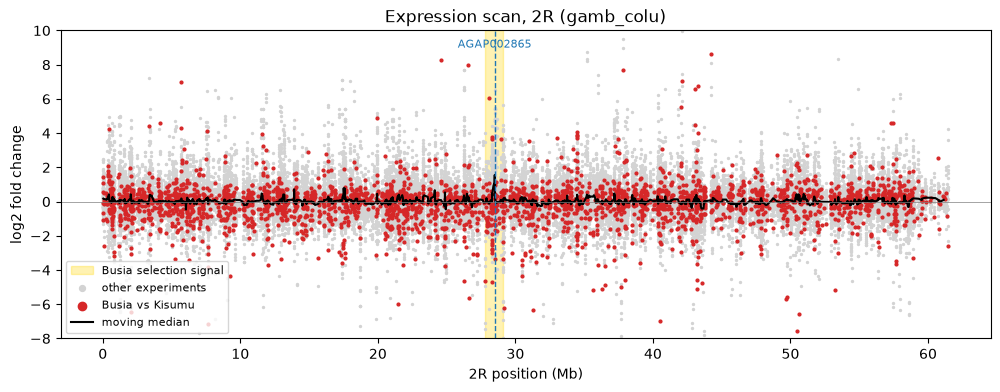

In [12]:
gff = xpress.load_gff(method="malariagen_data")  # gene positions, on compound contigs (see below)

# selection-atlas H12 signals (span2) for cohort UG-E_Busia_gamb_2016_Q2, in arm coordinates
BUSIA_SIGNALS = [
    ("2R", 27_764_792, 29_127_297),  # Cyp6aa/Cyp6p cluster
    ("2L", 33_561_345, 34_512_189),  # 2L ~34 Mb
    ("3R", 28_446_418, 28_846_415),  # Gste cluster
    ("X", 14_415_795, 16_192_993),   # Cyp9k1
]


def gene_arm(gene_id):
    """Chromosome arm (2R, 2L, 3R, 3L or X) of a gene."""
    g = gff.query("GeneID == @gene_id").iloc[0]
    if g.contig == "2RL":
        return "2R" if g.start <= 61_545_105 else "2L"
    if g.contig == "3RL":
        return "3R" if g.start <= 53_200_684 else "3L"
    return g.contig


def plot_scan(contig, analysis="gamb_colu", size=10, step=2, xlim=None):
    fcs, windowed = xpress.contig_expression(contig=contig, analysis=analysis, size=size, step=step)
    fcs = fcs.dropna(subset=["fold_change"])
    other, busia = fcs.query("comparison != @BUSIA"), fcs.query("comparison == @BUSIA")

    fig, ax = plt.subplots(figsize=(12, 4))
    for arm, start, end in BUSIA_SIGNALS:
        if arm == contig:
            ax.axvspan(start / 1e6, end / 1e6, color="gold", alpha=0.3, label="Busia selection signal")
    ax.scatter(other.midpoint / 1e6, other.fold_change, s=2, color="lightgrey", label="other experiments")
    ax.scatter(busia.midpoint / 1e6, busia.fold_change, s=4, color="tab:red", label="Busia vs Kisumu")
    ax.plot(windowed.midpoint / 1e6, windowed.median_fc, color="black", lw=1.5, label="moving median")
    for gene in CANDIDATE_GENES:
        hit = fcs.query("GeneID == @gene")
        if not hit.empty:
            ax.axvline(hit.midpoint.iloc[0] / 1e6, color="tab:blue", ls="--", lw=1)
            ax.text(hit.midpoint.iloc[0] / 1e6, 9, gene, color="tab:blue", fontsize=8, ha="center")
    ax.axhline(0, color="grey", lw=0.5)
    ax.set(xlabel=f"{contig} position (Mb)", ylabel="log2 fold change", ylim=(-8, 10), xlim=xlim,
           title=f"Expression scan, {contig} ({analysis})")
    ax.legend(loc="lower left", fontsize=8, markerscale=3)
    plt.show()


plot_scan("2R")

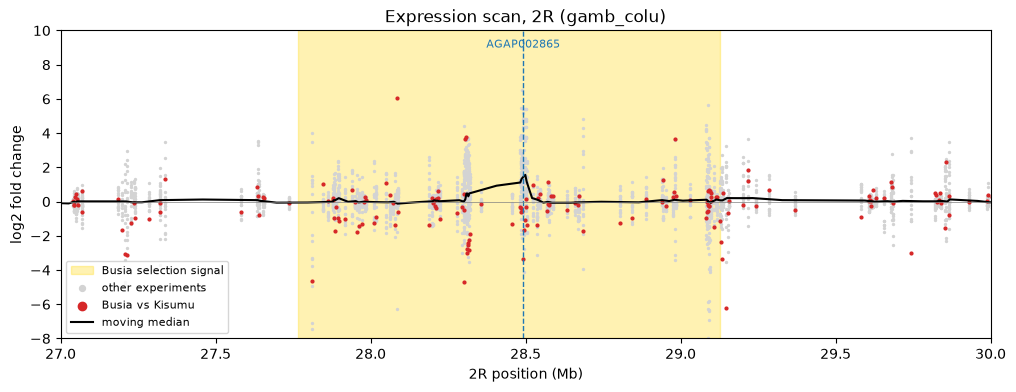

In [13]:
plot_scan("2R", xlim=(27, 30))  # zoom in on the Cyp6 cluster and the Busia signal

The moving median peaks at the *Cyp6aa/Cyp6p* cluster (about 28.5 Mb), right in the middle of the Busia
selection signal. The peak is driven by the other experiments (grey). The Busia points (red) at the cluster
sit below zero, while a few genes nearby, at about 28.3 Mb, are strongly up in Busia.

```{tip}
`xpress.plot_contig_expression(contig="2R", analysis="gamb_colu", show=True)` draws an interactive version
with a gene track underneath, which is handy for zooming and hovering. Its output is large (about 20 MB),
so we do not save it in this notebook.
```

The scan mixes all experiments. To see what Busia does in a region, pull out the fold changes for every gene
in a span and draw a heatmap. Genes are sorted by position.

AnoExpress uses **compound contigs** for regions: `2RL` is 2R followed by 2L, and `3RL` is 3R followed by
3L. Positions on 2R and 3R are the same as usual; positions on 2L and 3L are shifted by the length of 2R
(61,545,105 bp) or 3R (53,200,684 bp). `region_around()` below handles this for you.

```{note}
AnoExpress 0.3.3 downloads gene positions from VectorBase by default, and that download link no longer
works. Always pass `gff_method="malariagen_data"` when you give a genomic region or sort by position.
```

In [14]:
def region_around(gene_id, flank=100_000):
    """Return an AnoExpress region string (compound contigs) centred on a gene."""
    g = gff.query("GeneID == @gene_id").iloc[0]
    return f"{g.contig}:{max(1, g.start - flank)}-{g.end + flank}"


def region_heatmap(region, analysis="gamb_colu"):
    df = xpress.data(
        data_type="fcs", analysis=analysis, gene_id=region,
        gff_method="malariagen_data", sort_by="position", annotations=True,
    ).reset_index()
    df.index = df["GeneID"] + " " + df["GeneName"].fillna("")
    df = df.drop(columns=["GeneID", "GeneName", "GeneDescription"])
    return px.imshow(
        df, color_continuous_scale="RdBu_r", zmin=-6, zmax=6, aspect="auto",
        labels={"color": "log2FC"}, height=250 + 14 * len(df), width=900, title=region,
    )


region_heatmap("2RL:28,380,000-28,600,000")  # the Cyp6aa/Cyp6p cluster

CYP6AA1, CYP6P3 and CYP6P4 are red in most West African experiments, which fits a regulatory or CNV
mechanism spanning several genes. In the Busia column they are blue. Yet this region is the centre of a strong selection signal in
Busia (Day 3). A little further out, but still inside that signal, several genes *are* strongly up in
Busia: `AGAP002850`, `AGAP002852` and CYP6Z4 (`AGAP002894`) are all in the candidate pool.

Look closely at the six Côte d'Ivoire columns (Agboville, Dabou, Tiassale): CYP6P1 to CYP6P5 have
*identical* fold changes. That suggests reads from these very similar genes were counted together in that
study. Processing choices in the original studies carry through into any meta-analysis.

### Exercise 2

1. Run a genome-wide expression scan for the chromosome arm that carries your first candidate gene.
   Is the gene in a region where many neighbours are also overexpressed?
2. Draw a heatmap for 100 kb either side of each of your candidates using `region_around()` and
   `region_heatmap()`. Are neighbouring genes up in Busia too?
3. What would you look for on Day 3 to test whether a CNV explains the pattern?

<details><summary>Show answer</summary>

```python
gene = CANDIDATE_GENES[0]
plot_scan(gene_arm(gene))

for gene in CANDIDATE_GENES:
    region_heatmap(region_around(gene)).show()
```

For GSTE4 (`AGAP009193`), the neighbouring epsilon GSTs (GSTE3, GSTE5, GSTE6, GSTE7) are all modestly up in
Busia, while GSTE2 is down, so the whole cluster is not simply duplicated in this colony. On Day 3, check CNV
frequencies in the Ugandan Ag3 cohorts at the gene (`gene_cnv_frequencies()`), and whether a known CNV
(for example a *Gstue* or *Cyp6aap* duplication) covers it. If the duplication is common in Busia and covers
all the co-expressed genes, a CNV is a good explanation.

</details>

## Gene families

Most metabolic resistance genes belong to a few large families: cytochrome P450s, glutathione
S-transferases (GSTs), carboxylesterases (COEs), UDP-glucuronosyltransferases (UGTs) and ABC transporters.
Looking at the whole family shows whether your gene stands out from its relatives, or whether the whole
family moves together.

`plot_gene_family_expression()` takes a **Pfam domain** (short name) or a **GO term**, and plots every
gene that carries it. Useful Pfam names from the AnoExpress notebooks:

| Family | Pfam short names |
|---|---|
| Cytochrome P450s | `p450` |
| GSTs | `GST_N`, `GST_N_3`, `GST_C` |
| Carboxylesterases | `COesterase` |
| ABC transporters | `ABC_membrane`, `ABC_tran` |
| UGTs | `UDPGT` |
| Chemosensory proteins | `OS-D` |
| Odorant binding proteins | `PBP_GOBP` |

In [15]:
xpress.plot_gene_family_expression(
    gene_identifier=["GST_N", "GST_N_3", "GST_C"],
    analysis="gamb_colu",
    title="GSTs",
    sort_by="median",
    width=900,
)

## Co-expression

Genes that go up and down together across many experiments may share a regulator, sit on the same CNV,
or work in the same pathway. A simple way to find co-expressed genes is to correlate fold changes across
experiments. With only 18 `gamb_colu` comparisons the correlations are noisy, so treat the top hits as
leads, not conclusions.

The AnoExpress [gene regulatory network notebook](https://colab.research.google.com/github/sanjaynagi/AnoExpress/blob/main/workflow/notebooks/gene-regulatory-network.ipynb)
goes further, using GENIE3 to link transcription factors to their likely targets.

In [16]:
def coexpressed(gene_id, n=15, min_comparisons=12):
    ok = fc.notna().sum(axis=1) >= min_comparisons
    r = fc[ok].T.corrwith(fc.loc[gene_id]).drop(gene_id).dropna()
    top = r.sort_values(ascending=False).head(n).rename("pearson_r").to_frame()
    top = top.join(annots).join(gff.set_index("GeneID")[["contig", "start"]])
    top["same_region"] = (top["contig"] == gff.query("GeneID == @gene_id")["contig"].iloc[0]) & (
        (top["start"] - gff.query("GeneID == @gene_id")["start"].iloc[0]).abs() < 500_000
    )
    return top


coexpressed(CANDIDATE_GENES[0])

,pearson_r,GeneName,GeneDescription,contig,start,same_region
GeneID,,,,,,
AGAP028057,0.892715,NaN,NaN,3RL,10912886,False
AGAP000109,0.889806,NaN,cytochrome c oxidase subunit VIIa [Source:VB Community A...,X,1792391,False
AGAP008900,0.887001,NaN,facilitated trehalose transporter Tret1-2 homolog [Sourc...,3RL,20574664,False
AGAP002867,0.884205,CYP6P4,cytochrome P450 [Source:VB Community Annotation],2RL,28497087,True
AGAP000063,0.883108,NaN,paired box protein [Source:VB Community Annotation],X,979189,False
AGAP000209,0.877393,NaN,glutamate receptor binding protein [Source:VB Community ...,X,3462170,False
AGAP012176,0.875498,NaN,NaN,3RL,91540093,False
AGAP003241,0.874237,NaN,NaN,2RL,34378099,False
AGAP003430,0.869291,VhaM8.9,vacuolar H+ ATPase M8.9 accessory subunit [Source:VB Com...,2RL,37684196,False


The `same_region` column flags hits within 500 kb of your gene. Neighbouring genes at the top of the list
point towards a shared CNV or regulatory region.

### Exercise 3

1. List the genes most co-expressed with each of your candidates. Are any of them known resistance genes
   (P450s, GSTs, COEs, *Sap* genes)?
2. Are any of the co-expressed genes physical neighbours? What does that suggest?
3. Plot the fold changes of your gene and its top three partners with `plot_gene_expression()`.

<details><summary>Show answer</summary>

```python
for gene in CANDIDATE_GENES:
    display(coexpressed(gene))

top = coexpressed(CANDIDATE_GENES[0]).index[:3].to_list()
xpress.plot_gene_expression(gene_id=[CANDIDATE_GENES[0]] + top, analysis="gamb_colu", width=900, height=400)
```

For CYP6P3, its neighbour CYP6P4 is among the top hits (`same_region` is True), consistent with the
cluster being regulated or duplicated as a unit. But most top hits are unrelated genes scattered around the
genome with correlations above 0.85. With only 18 data points, many genes correlate strongly by chance, so
use co-expression to generate hypotheses, not to confirm them.

</details>

## Enrichment

Finally, zoom out. Which kinds of genes are overexpressed in Busia, and which are overexpressed consistently
across experiments? A **hypergeometric test** asks whether a gene list contains more members of a GO term or
Pfam domain than expected by chance, given how many genes carry it genome-wide. AnoExpress corrects the
p-values for multiple testing (Benjamini-Hochberg).

Here we test the genes that are significantly overexpressed in at least 10 of the 18 `gamb_colu` comparisons.

In [17]:
n_up = ((fc > 0) & (padj < 0.05)).sum(axis=1)
consistent = n_up[n_up >= 10].index.to_list()
print(f"{len(consistent)} genes overexpressed in >= 10 comparisons")

pfam_enrich = xpress.pfam_hypergeometric(analysis="gamb_colu", gene_ids=consistent)
pfam_enrich.query("padj < 0.05")

235 genes overexpressed in >= 10 comparisons


,annotation,pval,padj
688,p450,8.904039e-23,3.684491e-19
704,Sushi,4.714831e-06,9.754986e-03


### Exercise 4

1. Repeat the Pfam enrichment for genes that are significantly overexpressed in Busia with log2FC > 2.
   Which gene families are enriched? Are they the same as in the consistent set?
2. Run a GO enrichment on the same list with `xpress.go_hypergeometric()`. Which terms come up?
3. Is your gene in an enriched family? Does that make it a stronger or a weaker candidate?

<details><summary>Show answer</summary>

```python
busia_up = fc.index[(fc[BUSIA] > 2) & (padj[BUSIA] < 0.05)].to_list()
print(len(busia_up))
display(xpress.pfam_hypergeometric(analysis="gamb_colu", gene_ids=busia_up).query("padj < 0.05"))
display(xpress.go_hypergeometric(analysis="gamb_colu", gene_ids=busia_up).head(15))
```

The consistent set is dominated by P450s (`p450`). The Busia list is less clean: many of its most
overexpressed genes are unannotated, and those drop out of an annotation-based test. Being in an enriched
family (for example a P450) raises the prior that a gene can metabolise insecticide, but it does not make
it more likely to be *the* causal gene in Busia. Selection (Day 3) and association with survival (Day 4)
are stronger evidence.

</details>

### Exercise 5: update your dossier

Write the **Replication** section of your gene dossier for each candidate. Include:

- the Busia log2FC and adjusted p-value;
- the number of `gamb_colu` comparisons with significant over- and underexpression, and where they are from;
- whether neighbouring genes are co-overexpressed (possible CNV), and the gene's top co-expressed partners;
- your judgement: is the Busia result replicated, Busia-specific, or contradicted elsewhere?

## Quiz

In [18]:
%pip install -q jupyterquiz
from jupyterquiz import display_quiz
display_quiz("https://raw.githubusercontent.com/sanjaynagi/malaria-software-training/main/quizzes/2-3-anoexpress.json")

Note: you may need to restart the kernel to use updated packages.


<IPython.core.display.Javascript object>

## Summary

- One RNA-seq experiment cannot separate resistance genes from colony differences. Replication across
  independent studies is a cheap, powerful filter.
- AnoExpress gives comparable fold changes and adjusted p-values for many resistant vs susceptible
  comparisons, including Busia. It is a collection, not a pooled test: count, look and think.
- Fold changes depend on the reference strain. Busia's CYP6P3 and GSTE2 are *lower* than in this batch of
  Kisumu, even though both genes lie in Busia selective sweeps.
- Genome-wide expression scans and region heatmaps reveal clusters of co-overexpressed neighbours, which
  often point to CNVs, the topic of Day 3.
- Gene families, co-expression and enrichment put a candidate in context, but they add prior plausibility
  rather than direct evidence.

## Well done!

You now know whether your genes replicate. Tomorrow you ask *why* they are overexpressed, and whether
they are under selection in wild Ugandan and Kenyan mosquitoes.

## References

1. Nagi SC, Ingham VA. AnoExpress: *Anopheles* gene expression in resistance studies. Python package and
   Colab notebooks, https://github.com/sanjaynagi/AnoExpress (version 0.3.3).
2. Nagi SC, Oruni A, Weetman D, Donnelly MJ (2023). RNA-Seq-Pop: Exploiting the sequence in RNA
   sequencing, a Snakemake workflow reveals patterns of insecticide resistance in the malaria vector
   *Anopheles gambiae*. *Molecular Ecology Resources* 23: 946–961. https://doi.org/10.1111/1755-0998.13759
3. Ingham VA, Wagstaff S, Ranson H (2018). Transcriptomic meta-signatures identified in *Anopheles gambiae*
   populations reveal previously undetected insecticide resistance mechanisms. *Nature Communications* 9: 5282.
   https://doi.org/10.1038/s41467-018-07615-x
4. Ingham VA, Anthousi A, Douris V, *et al.* (2020). A sensory appendage protein protects malaria vectors
   from pyrethroids. *Nature* 577: 376–380. https://doi.org/10.1038/s41586-019-1864-1
5. Love MI, Huber W, Anders S (2014). Moderated estimation of fold change and dispersion for RNA-seq data
   with DESeq2. *Genome Biology* 15: 550. https://doi.org/10.1186/s13059-014-0550-8
6. Ingham VA, Morgan J, Lees RS, Ranson H (2019). Characterisation of *Anopheles* strains used for laboratory
   screening of new vector control products. *Parasites & Vectors* 12.
   https://doi.org/10.1186/s13071-019-3774-3
7. Njoroge H, van't Hof A, Oruni A, *et al.* (2022). Identification of a rapidly-spreading triple mutant for
   high-level metabolic insecticide resistance in *Anopheles gambiae* provides a real-time molecular
   diagnostic for antimalarial intervention deployment. *Molecular Ecology* 31: 4307–4318.
   https://doi.org/10.1111/mec.16591